# Week-9

[INFO] Foodwebs with Nodes > 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 290


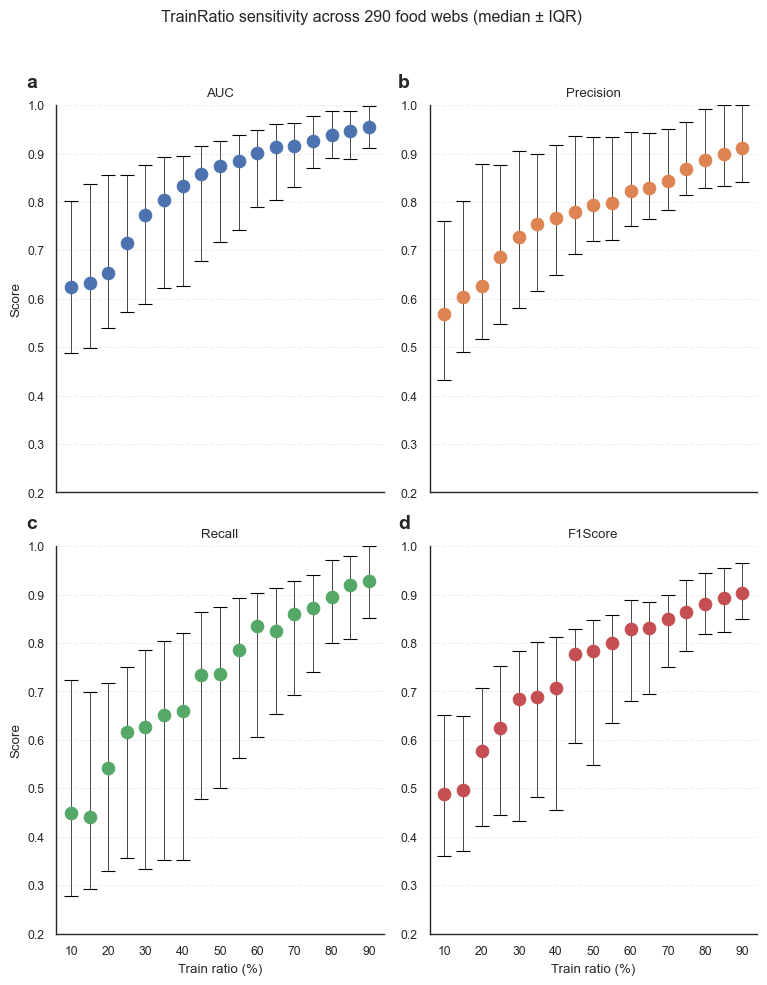

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_sweep_train_ratios_10-90/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None
METRICS = ["AUC", "Precision", "Recall", "F1Score"]
MAX_PLOTS = None
NODES_THRESHOLD = 0
SHOW_GRID = True
Y_MIN = 0.2

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    ax.set_xticks(train_ratios)
    ax.set_xticklabels([str(t) if t % 10 == 0 else "" for t in train_ratios])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

allowed_fw_keys = set(meta.loc[meta[nodes_col] > NODES_THRESHOLD, "FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes > {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()
df.drop(columns="FW_KEY", inplace=True)

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, train ratio, and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

# Consistent metric colors
deep4 = sns.color_palette("deep", 4)
metric_colors = {
    "AUC": deep4[0],
    "Precision": deep4[1],
    "Recall": deep4[2],
    "F1Score": deep4[3],
}

# =========================
# Final plot
# =========================
fig, axes = plt.subplots(2, 2, figsize=(8, 10), sharex=True, sharey=False)
axes = axes.ravel()
panel_letters = ["a", "b", "c", "d"]

for i, (ax, metric) in enumerate(zip(axes, metrics_present)):
    sub = summary[summary["Metric"] == metric].sort_values("TRAINRATIO")

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["median"].to_numpy()
    yerr = np.vstack([
        (sub["median"] - sub["q25"]).to_numpy(),
        (sub["q75"] - sub["median"]).to_numpy(),
    ])

    color = metric_colors[metric]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=9,
        linewidth=1.6,
        elinewidth=0.5,
        capsize=5,
        capthick=1,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.8,
    )

    ax.set_title(metric)
    ax.set_ylim(Y_MIN, 1.0)

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    set_trainratio_ticks(ax, train_ratios)
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1),
        xycoords="axes fraction",
        xytext=(-14, 10),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=14,
        fontweight="bold",
        annotation_clip=False,
    )

# Hide unused axes if fewer than 4 metrics are present
for k in range(len(metrics_present), 4):
    axes[k].set_axis_off()

for ax in axes[2:]:
    ax.set_xlabel("Train ratio (%)")

for ax in axes[::2]:
    ax.set_ylabel("Score")

fig.suptitle(
    f"TrainRatio sensitivity across {n_webs} food webs (median ± IQR)",
    y=0.98
)

fig.tight_layout(rect=[0.03, 0, 1, 0.96])
plt.show()

[INFO] Foodwebs with Nodes > 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 290
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']


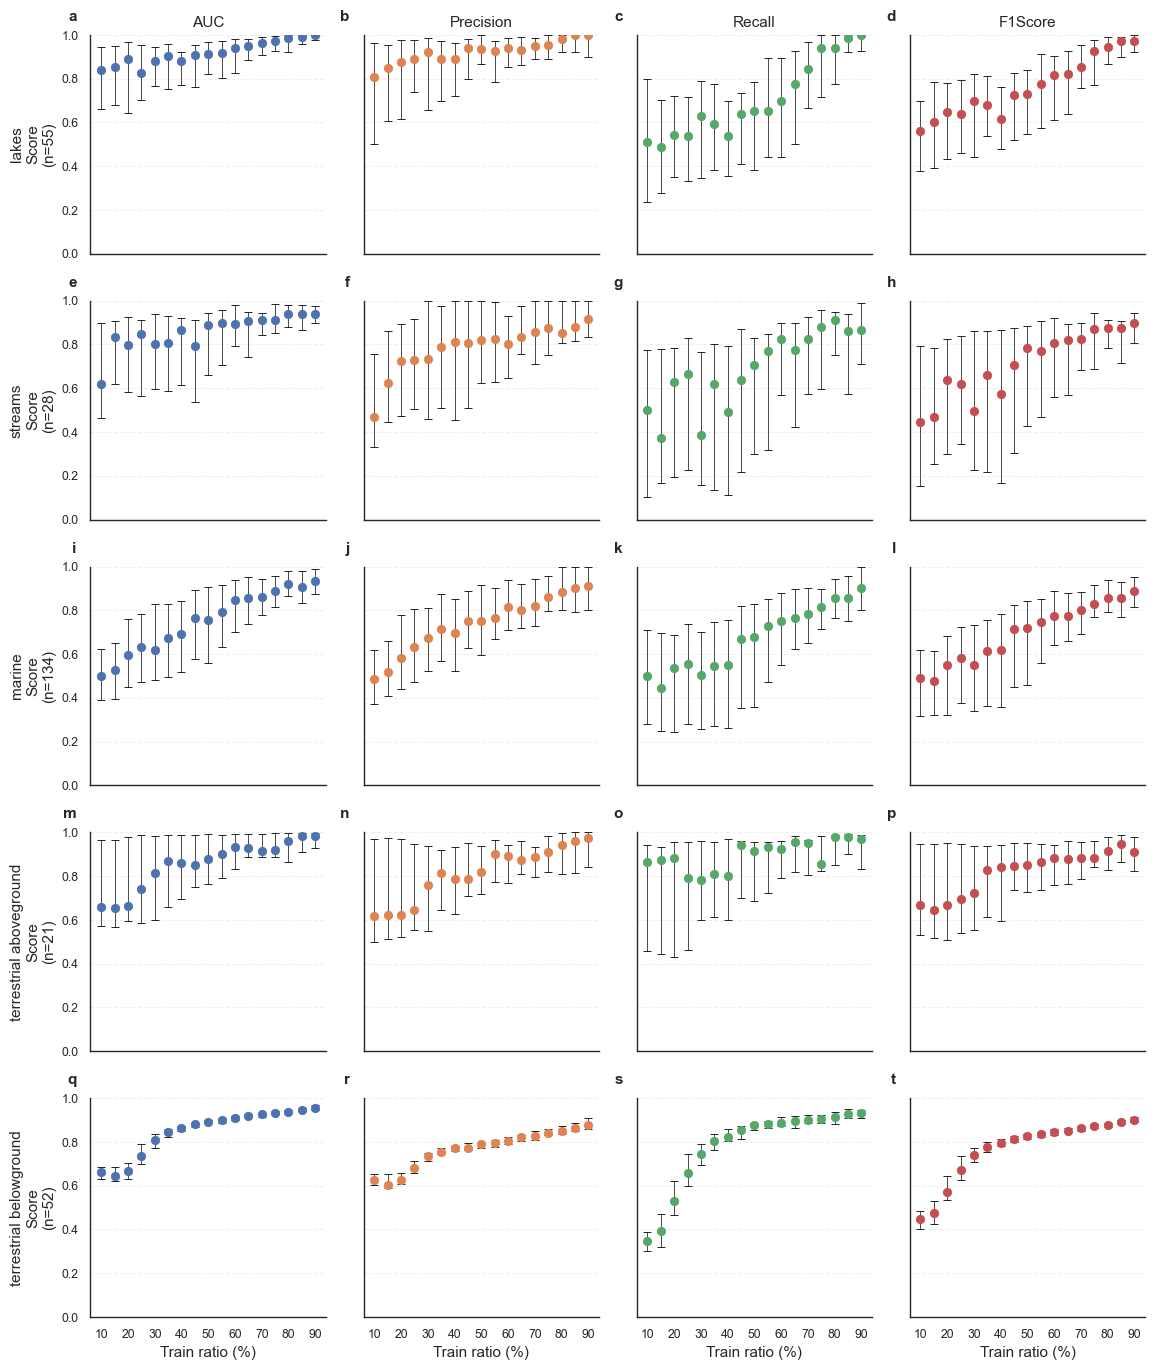

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_sweep_train_ratios_10-90/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None
METRICS = ["AUC", "Precision", "Recall", "F1Score"]
MAX_PLOTS = None
NODES_THRESHOLD = 0
SHOW_GRID = True
Y_MIN = 0

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    ax.set_xticks(train_ratios)
    ax.set_xticklabels([str(t) if t % 10 == 0 else "" for t in train_ratios])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] > NODES_THRESHOLD, ["FW_KEY", ecosystem_col]].copy()
meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes > {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, ecosystem, train ratio, and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "ECOSYSTEM", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["ECOSYSTEM", "TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

# Define preferred order for ecosystems
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = summary["ECOSYSTEM"].dropna().unique().tolist()

ecosystem_order = [e for e in preferred_ecosystem_order if e in ecosystems_present]

# fallback: append any unmatched ecosystem names
ecosystem_order += [e for e in ecosystems_present if e not in ecosystem_order]

# Consistent metric colors
deep4 = sns.color_palette("deep", 4)
metric_colors = {
    "AUC": deep4[0],
    "Precision": deep4[1],
    "Recall": deep4[2],
    "F1Score": deep4[3],
}
# =========================
# Final plot: ecosystems x metrics
# Rows = ecosystems, Columns = metrics
# =========================
n_rows = len(ecosystem_order)
n_cols = len(metrics_present)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(12, 14),
    sharex=True,
    sharey=True
)

# Make axes always 2D
if n_rows == 1:
    axes = np.array([axes])
if n_cols == 1:
    axes = axes[:, np.newaxis]

panel_letters = list("abcdefghijklmnopqrst")
letter_idx = 0

for r, ecosystem in enumerate(ecosystem_order):
    for c, metric in enumerate(metrics_present):
        ax = axes[r, c]

        sub = summary[
            (summary["ECOSYSTEM"] == ecosystem) &
            (summary["Metric"] == metric)
        ].sort_values("TRAINRATIO")

        if sub.empty:
            ax.set_axis_off()
            continue

        x = sub["TRAINRATIO"].to_numpy()
        y = sub["median"].to_numpy()
        yerr = np.vstack([
            (sub["median"] - sub["q25"]).to_numpy(),
            (sub["q75"] - sub["median"]).to_numpy(),
        ])

        color = metric_colors[metric]

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="o",
            linestyle="none",
            color=color,
            ecolor="black",
            markersize=6,
            linewidth=1.2,
            elinewidth=0.5,
            capsize=3,
            capthick=0.8,
            markerfacecolor=color,
            markeredgecolor=color,
            markeredgewidth=0.6,
        )

        ax.set_ylim(Y_MIN, 1.0)

        if SHOW_GRID:
            ax.grid(True, axis="y", linestyle="--", alpha=0.30)
        else:
            ax.grid(False)

        set_trainratio_ticks(ax, train_ratios)
        sns.despine(ax=ax)

        # Column titles only on first row
        if r == 0:
            ax.set_title(metric, fontsize=11)

        # Row labels only on first column
        if c == 0:
            n_ecosystem_webs = df_web_means.loc[
                df_web_means["ECOSYSTEM"] == ecosystem, "FOODWEB"
            ].nunique()
            ax.set_ylabel(f"{ecosystem}\nScore\n(n={n_ecosystem_webs})", fontsize=11)

        # x label only on bottom row
        if r == n_rows - 1:
            ax.set_xlabel("Train ratio (%)", fontsize=11)

        # Panel letters
        if letter_idx < len(panel_letters):
            ax.annotate(
                panel_letters[letter_idx],
                xy=(0, 1),
                xycoords="axes fraction",
                xytext=(-10, 8),
                textcoords="offset points",
                ha="right",
                va="bottom",
                fontsize=11,
                fontweight="bold",
                annotation_clip=False,
            )
            letter_idx += 1

# fig.suptitle(
#     "TrainRatio sensitivity by ecosystem type (median ± IQR)",
#     y=0.995,
#     fontsize=14
# )

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

Filtered food webs by size: kept 160 / 290 (>= 40 nodes).


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_49241/1544940843.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_49241/1544940843.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_49241/1544940843.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_49241/1544940843.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

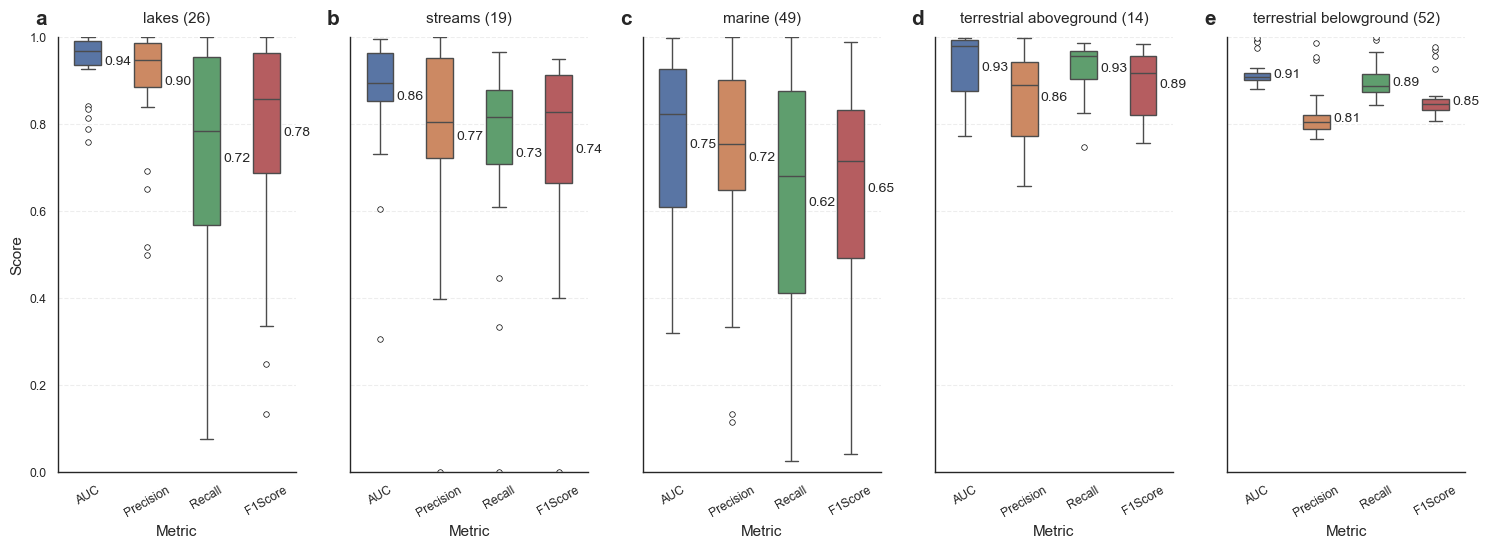

In [1]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_sweep_train_ratios_10-90/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["AUC", "Precision", "Recall", "F1Score"]
MIN_NODES = 40

# Seaborn "deep" first 4 colors: blue, orange, green, red
metric_palette = dict(zip(METRIC_ORDER, sns.color_palette("deep", 4)))

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

# Detect node-count column robustly
node_candidates = {
    "n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"
}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_results_random.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left"
)

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Prepare long-format data ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "Iteration"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value"
)

# Robust filtering later expects numeric compatibility
df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

# Keep original labels from the data, but match using lowercase
ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

# Append any unexpected ecosystem labels not covered above
ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)
labels_map = {eco: f"{eco} ({n})" for eco, n in labels_map.items()}

# === Filter TrainRatio = 60 ===
subset = df_plot[pd.to_numeric(df_plot["TrainRatio"], errors="coerce") == 60.0].copy()
if subset.empty:
    raise RuntimeError("No rows for TrainRatio = 60.0. Check how TrainRatio is stored.")

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True
)

# === Plot: 1xN horizontal layout ===
n_panels = len(ecosystem_order)
fig, axes = plt.subplots(
    1, n_panels,
    figsize=(3 * n_panels, 6),
    sharey=True
)

if n_panels == 1:
    axes = [axes]

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, (ax, eco) in enumerate(zip(axes, ecosystem_order)):
    sub = subset[subset["EcosystemType"] == eco].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="Metric",
        y="Value",
        order=METRIC_ORDER,
        palette=metric_palette,
        showfliers=True,
        width=0.45,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    # Annotate one summary value per box (recommended: mean)
    for j, metric in enumerate(METRIC_ORDER):
        vals = sub.loc[sub["Metric"] == metric, "Value"].dropna()
        if vals.empty:
            continue

        stat = vals.mean()   # or vals.mean() if you want mean instead

        ax.text(
            j + 0.28,           # slightly to the right of the box center
            stat,
            f"{stat:.2f}",
            ha="left",
            va="center",
            fontsize=10,
        )

    # sp = sns.stripplot(
    #     data=sub,
    #     x="Metric",
    #     y="Value",
    #     hue="Metric",
    #     hue_order=METRIC_ORDER,
    #     palette=metric_palette,
    #     dodge=False,
    #     jitter=0.20,
    #     alpha=1.0,
    #     linewidth=0.5,
    #     edgecolor="black",
    #     size=4.2,
    #     ax=ax,
    #     zorder=2,
    # )

    # for coll in sp.collections:
    #     coll.set_facecolor("none")
    #     coll.set_alpha(1.0)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_title(labels_map.get(eco, eco), fontsize=11, pad=10)
    ax.set_xlabel("Metric", fontsize=11)
    ax.set_ylabel("Score" if i == 0 else "", fontsize=11)
    ax.set_ylim(0, 1.0)

    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.grid(False, axis="x")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=15,
        fontweight="bold",
        annotation_clip=False,
    )

    ax.tick_params(axis="x", rotation=30)

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Processing: Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2


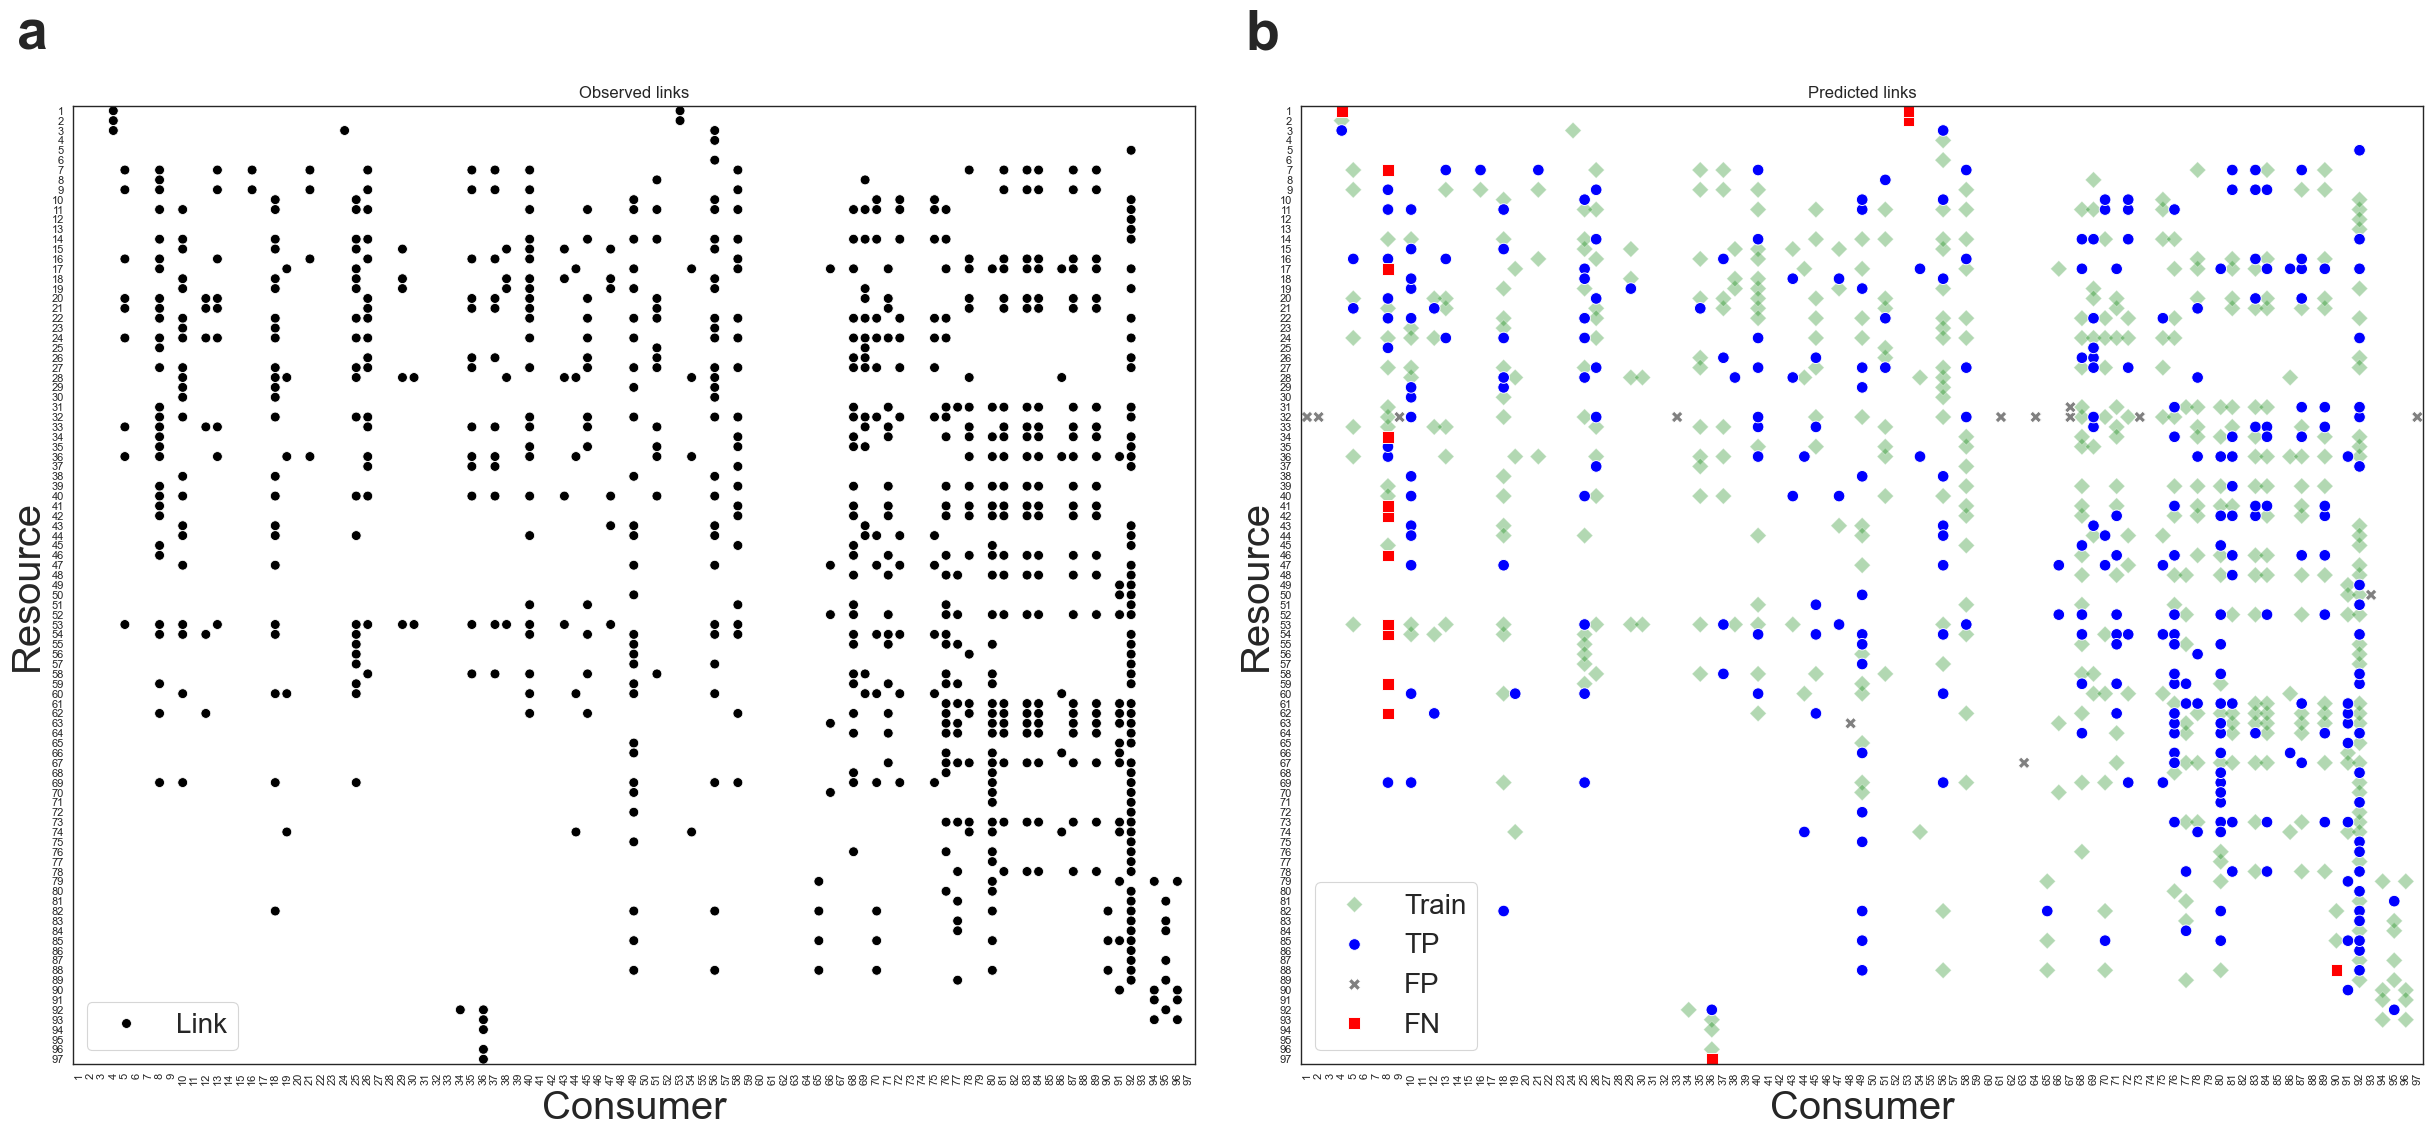

In [4]:
import os
import re
import scipy.io
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix, csr_matrix

# Apply seaborn style
sns.set_theme(context="paper", style="white", font_scale=3)

# =========================
# Figure controls (flags)
# =========================
MAX_PLOTS = 1

SHOW_TITLES = True          # toggle subplot titles on/off
SHOW_TICKS = True           # toggle tick labels + tick marks on/off

# Paper-friendly labels (only used if SHOW_TITLES=True)
TITLE_LEFT = "Observed links"
TITLE_RIGHT = "Predicted links"

# Paper-friendly axis labels (optional: keep short)
XLAB = "Consumer"
YLAB = "Resource"

# =========================
# NEW: numeric axis labels + species key printing
# =========================
USE_NUMERIC_AXIS_LABELS = True   # axis shows 1..N instead of species names
PRINT_SPECIES_KEY = False         # print Number <-> Species mapping
EXPORT_SPECIES_KEY_FILE = False
SPECIES_KEY_DIR = "./species_keys"   # folder to save keys
SPECIES_KEY_FORMAT = "csv"           # "tsv" (best for Word) or "csv"

# =========================
# NEW: plot a specific foodweb (optional)
# =========================
# Set to None to run as before.
# Or set to a string like: "ChesapeakeBay" or "ChesapeakeBay_tax_mass"
TARGET_FOODWEB = "Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2"
# TARGET_FOODWEB = "Ythan Estuary"

# === Load foodweb names list ===
foodwebs_list_df = pd.read_csv("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

# === Base paths ===
base_csv_path = "../../../src/matlab/data/result_trainRatio_60_backboneRatio_50/confusion_matrix_csv"
base_mat_path = "../../../src/matlab/data/foodwebs_mat"

plots_done = 0

# =========================
# NEW: choose which foodwebs to iterate
# =========================
all_foodwebs = foodwebs_list_df["Foodweb"].astype(str).tolist()

if TARGET_FOODWEB is None:
    foodweb_iter = all_foodwebs
else:
    # allow passing either exact name in CSV OR name without suffix
    # try exact match first, otherwise match by prefix before first "_"
    exact = [fw for fw in all_foodwebs if fw == TARGET_FOODWEB]
    if exact:
        foodweb_iter = exact
    else:
        prefix_matches = [fw for fw in all_foodwebs if fw.split("_")[0] == TARGET_FOODWEB]
        foodweb_iter = prefix_matches

    if not foodweb_iter:
        raise ValueError(
            f"TARGET_FOODWEB='{TARGET_FOODWEB}' not found in foodweb list. "
            f"Example valid values: {all_foodwebs[:5]}"
        )

# === Iterate over each foodweb (same logic) ===
for foodweb in foodweb_iter:
    if plots_done >= MAX_PLOTS:
        break

    print(f"\nProcessing: {foodweb.split('_')[0]}")

    try:
        # === Load CSV prediction results ===
        tp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_TP_links.csv")
        fp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_FP_links.csv")
        fn_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_FN_links.csv")
        train_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_train_links.csv")
        mat_file = os.path.join(base_mat_path, f"{foodweb}.mat")

        tp = pd.read_csv(tp_file).dropna(subset=['Prey', 'Predator'])
        fp = pd.read_csv(fp_file).dropna(subset=['Prey', 'Predator'])
        fn = pd.read_csv(fn_file).dropna(subset=['Prey', 'Predator'])

        # === Load .mat adjacency and metadata ===
        mat_data = scipy.io.loadmat(mat_file)
        net = mat_data['net']
        taxonomy = [str(t[0]) if isinstance(t, (list, np.ndarray)) else str(t) for t in mat_data['taxonomy'].flatten()]
        mass = mat_data["mass"].flatten().astype(float)  # ensure numeric
        mass = np.round(mass * 1000.0, 4)  # g -> mg, keep max 4 decimals

        # === Sort species by mass ===
        taxonomy_df = pd.DataFrame({'Species': taxonomy, 'Mass': mass})
        taxonomy_df = taxonomy_df.dropna().sort_values(by='Mass').reset_index(drop=True)
        sorted_species = taxonomy_df['Species'].tolist()
        species_index = {name: i for i, name in enumerate(sorted_species)}
        N = len(sorted_species)
        sorted_species_reversed = sorted_species[::-1]

        # =========================
        # NEW: number each species (1..N) in mass-ascending order (same as x-axis order)
        # =========================
        species_to_num = {sp: i + 1 for i, sp in enumerate(sorted_species)}  # 1..N
        num_to_species = {i + 1: sp for i, sp in enumerate(sorted_species)}

        if PRINT_SPECIES_KEY:
            key_df = taxonomy_df.copy()
            key_df["Number"] = np.arange(1, len(key_df) + 1)
            key_df = key_df[["Number", "Species", "Mass"]].rename(columns={"Mass": "Mass_mg"})
            key_df["Mass_mg"] = key_df["Mass_mg"].map(lambda x: f"{x:.4f}")

            # --- 1) Nice console view (optional)
            print("\nSpecies key (pretty):")
            print(key_df.to_string(index=False))

            if EXPORT_SPECIES_KEY_FILE:
                out_dir = Path(SPECIES_KEY_DIR)
                out_dir.mkdir(parents=True, exist_ok=True)

                # sanitize foodweb name for filename (spaces/special chars -> "_")
                safe_fw = re.sub(r"[^A-Za-z0-9._-]+", "_", str(foodweb)).strip("_")

                ext = "tsv" if SPECIES_KEY_FORMAT.lower() == "tsv" else "csv"
                out_path = out_dir / f"{safe_fw}_species_key.{ext}"

                sep = "\t" if ext == "tsv" else ","
                key_df.to_csv(out_path, sep=sep, index=False, encoding="utf-8")

                print(f"\nSaved species key file to: {out_path.resolve()}")

        # === Sort adjacency matrix by mass ===
        if isinstance(net, coo_matrix):
            net = net.tocsr()
        elif isinstance(net, (np.ndarray, list)):
            net = csr_matrix(net)
        idx_sorted = [taxonomy.index(sp) for sp in sorted_species]
        adj_sorted = net[np.ix_(idx_sorted, idx_sorted)].toarray().astype(float)

        # === Build DataFrame for Adjacency Matrix (non-zero links) ===
        am_rows, am_cols = np.where(adj_sorted == 1)
        df_am = pd.DataFrame({
            'PreyIdx': N - 1 - am_rows,  # flip y-axis
            'PredIdx': am_cols,
            'Label': 'Link'
        })

        # === Filter predictions to valid species ===
        tp = tp[tp['Prey'].isin(species_index) & tp['Predator'].isin(species_index)]
        fp = fp[fp['Prey'].isin(species_index) & fp['Predator'].isin(species_index)]
        fn = fn[fn['Prey'].isin(species_index) & fn['Predator'].isin(species_index)]

        # === Build DataFrame for Predation Matrix
        def make_df(df, label):
            return pd.DataFrame({
                'PreyIdx': df['Prey'].map(species_index),
                'PredIdx': df['Predator'].map(species_index),
                'Label': label
            })

        df_pm = pd.concat([
            make_df(tp, 'TP'),
            make_df(fp, 'FP'),
            make_df(fn, 'FN')
        ]).dropna().astype({'PreyIdx': int, 'PredIdx': int})
        df_pm['PreyIdx'] = N - 1 - df_pm['PreyIdx']

        # === Load Training Links (if available)
        df_train = None
        if os.path.isfile(train_file):
            train = pd.read_csv(train_file).dropna(subset=['Prey', 'Predator'])
            train = train[train['Prey'].isin(species_index) & train['Predator'].isin(species_index)]
            df_train = pd.DataFrame({
                'PreyIdx': train['Prey'].map(species_index),
                'PredIdx': train['Predator'].map(species_index),
                'Label': 'Train'
            })
            df_train['PreyIdx'] = N - 1 - df_train['PreyIdx']

        # === Plotting
        fig, axs = plt.subplots(1, 2, figsize=(25, 12))

        # Panel labels (top-left corner, outside each axis)
        axs[0].text(-0.05, 1.1, "a", transform=axs[0].transAxes,
                    fontsize=40, fontweight="bold", va="top", ha="left", clip_on=False)
        axs[1].text(-0.05, 1.1, "b", transform=axs[1].transAxes,
                    fontsize=40, fontweight="bold", va="top", ha="left", clip_on=False)

        # LEFT: Adjacency Matrix
        sns.scatterplot(
            data=df_am, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
            markers={'Link': 'o'}, palette={'Link': 'black'}, s=50, ax=axs[0]
        )

        # RIGHT: Predation Matrix
        ax = axs[1]

        # Plot training links first (background), with low opacity and include in legend
        if df_train is not None:
            sns.scatterplot(
                data=df_train, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
                markers={'Train': 'D'}, palette={'Train': 'green'},
                alpha=0.3, s=70, legend='brief', ax=ax
            )

        # Plot TP, FP, FN
        sns.scatterplot(
            data=df_pm, x='PredIdx', y='PreyIdx', hue='Label', style='Label',
            markers={'TP': 'o', 'FP': 'X', 'FN': 's', 'Train': 'D'},
            palette={'TP': 'blue', 'FP': 'gray', 'FN': 'red', 'Train': 'green'},
            s=70, ax=ax
        )

        # =========================
        # Professional axes styling
        # =========================
        for a in axs:
            a.invert_yaxis()
            a.set_xlim(-0.5, N - 0.5)
            a.set_ylim(-0.5, N - 0.5)

            if SHOW_TITLES:
                a.set_title(TITLE_LEFT if a is axs[0] else TITLE_RIGHT, fontsize=12)
            else:
                a.set_title("")

            a.set_xlabel(XLAB)
            a.set_ylabel(YLAB)

            if SHOW_TICKS:
                a.set_xticks(range(N))
                a.set_yticks(range(N))

                if USE_NUMERIC_AXIS_LABELS:
                    # X axis follows sorted_species (mass-ascending): 1..N
                    x_labels = [str(i) for i in range(1, N + 1)]

                    # Y axis currently uses sorted_species_reversed; label with the corresponding numbers
                    y_labels = [str(species_to_num[sp]) for sp in sorted_species_reversed]

                    a.set_xticklabels(x_labels, rotation=90, fontsize=8)
                    a.set_yticklabels(y_labels, fontsize=8)
                else:
                    a.set_xticklabels(sorted_species, rotation=90, fontsize=8)
                    a.set_yticklabels(sorted_species_reversed, fontsize=8)

                a.tick_params(axis='both', which='both', length=3)
            else:
                a.set_xticks([])
                a.set_yticks([])
                a.set_xticklabels([])
                a.set_yticklabels([])
                a.tick_params(axis='both', which='both', length=0)

        # Remove legend on left panel (as you had)
        # axs[0].legend([], [], frameon=False)
        ax.legend(loc='lower left', prop={'size': 20}, title="")
        axs[0].legend(loc='lower left', prop={'size': 20}, title="")

        plt.tight_layout()
        plt.show()

        plots_done += 1

    except Exception as e:
        print(f"Skipping {foodweb} due to error: {e}")

Filtered foodweb list by size: kept 160 / 290 (>= 40 nodes).

Processing: Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2


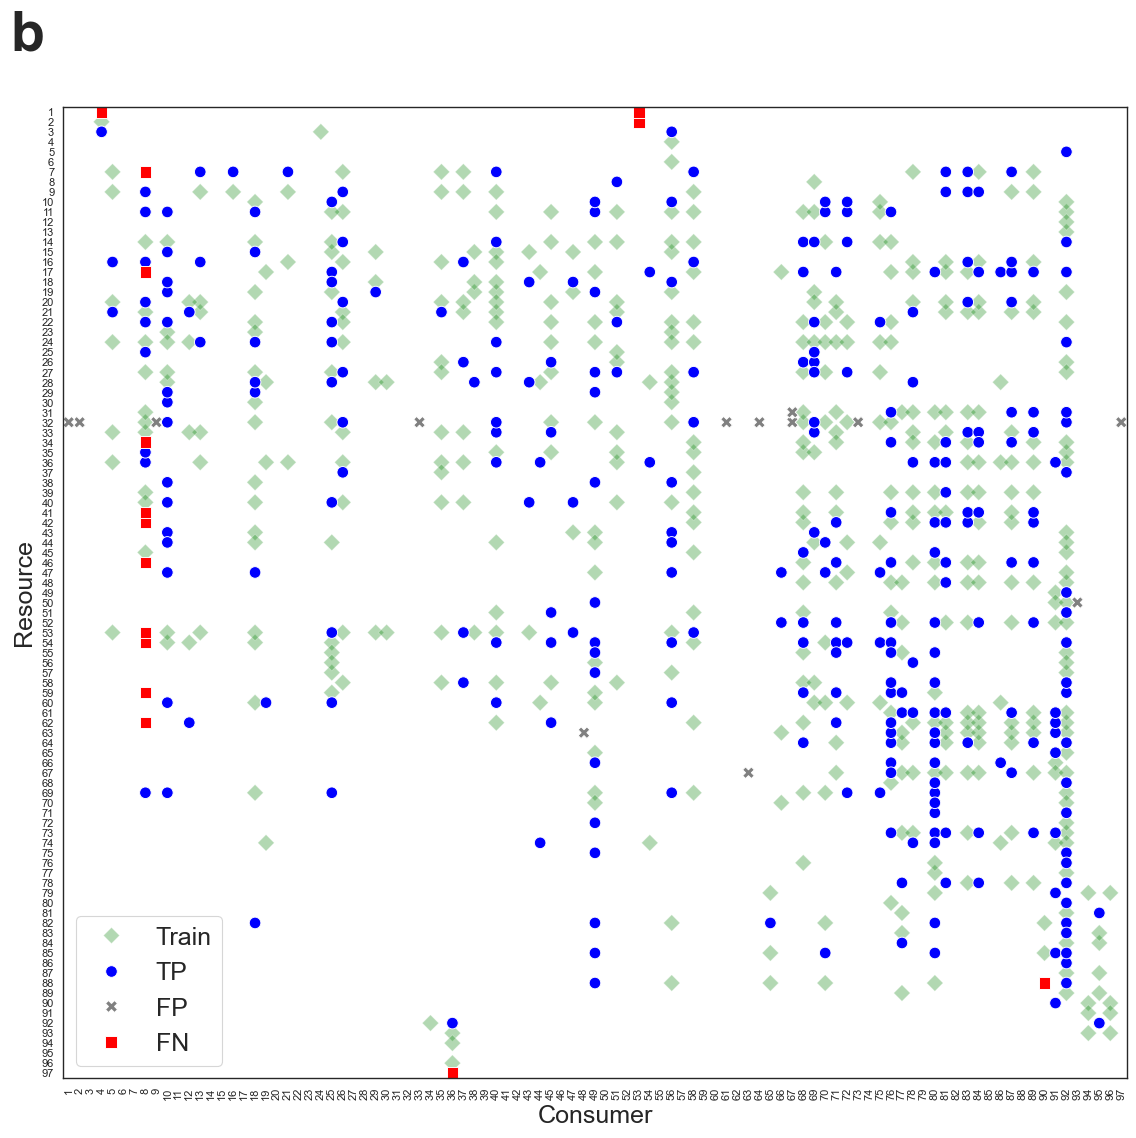

In [5]:
import os
import re
import scipy.io
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix, csr_matrix

# Apply seaborn style
sns.set_theme(context="paper", style="white", font_scale=3)

# =========================
# Figure controls (flags)
# =========================
MAX_PLOTS = 1
MIN_NODES = 40
PANEL_LETTER = "b"

SHOW_TITLES = True
SHOW_TICKS = True

XLAB = "Consumer"
YLAB = "Resource"

# =========================
# Numeric axis labels + species key printing
# =========================
USE_NUMERIC_AXIS_LABELS = True
PRINT_SPECIES_KEY = False
EXPORT_SPECIES_KEY_FILE = False
SPECIES_KEY_DIR = "./species_keys"
SPECIES_KEY_FORMAT = "csv"

# =========================
# Plot a specific foodweb (optional)
# =========================
# TARGET_FOODWEB = "Tuesday Lake 1984"
TARGET_FOODWEB = "Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2"
# TARGET_FOODWEB = "Ythan Estuary"

# === Load foodweb names list ===
foodwebs_list_df = pd.read_csv("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

# === Filter to foodwebs with nodes >= MIN_NODES ===
def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

node_candidates = {
    "n_nodes", "num_nodes", "nodes", "nodecount", "n", "s",
    "species", "numspecies", "numberofspecies", "speciescount"
}

norm_map = {normalize_colname(c): c for c in foodwebs_list_df.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in foodweb_metrics_ecosystem.csv. "
        "Please add one such as 'Nodes' or 'S'."
    )

before_n = len(foodwebs_list_df)
foodwebs_list_df = foodwebs_list_df[foodwebs_list_df[node_col] >= MIN_NODES].copy()
after_n = len(foodwebs_list_df)

print(f"Filtered foodweb list by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Base paths ===
base_csv_path = "../../../src/matlab/data/result_trainRatio_60_backboneRatio_50/confusion_matrix_csv"
base_mat_path = "../../../src/matlab/data/foodwebs_mat"

plots_done = 0

# =========================
# Choose which foodwebs to iterate
# =========================
all_foodwebs = foodwebs_list_df["Foodweb"].astype(str).tolist()

if TARGET_FOODWEB is None:
    foodweb_iter = all_foodwebs
else:
    exact = [fw for fw in all_foodwebs if fw == TARGET_FOODWEB]
    if exact:
        foodweb_iter = exact
    else:
        prefix_matches = [fw for fw in all_foodwebs if fw.split("_")[0] == TARGET_FOODWEB]
        foodweb_iter = prefix_matches

    if not foodweb_iter:
        raise ValueError(
            f"TARGET_FOODWEB='{TARGET_FOODWEB}' not found in foodweb list. "
            f"Example valid values: {all_foodwebs[:5]}"
        )

# === Iterate over each foodweb ===
for foodweb in foodweb_iter:
    if plots_done >= MAX_PLOTS:
        break

    print(f"\nProcessing: {foodweb.split('_')[0]}")

    try:
        # === Load CSV prediction results ===
        tp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_TP_links.csv")
        fp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_FP_links.csv")
        fn_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_FN_links.csv")
        train_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_train_links.csv")
        mat_file = os.path.join(base_mat_path, f"{foodweb}.mat")

        tp = pd.read_csv(tp_file).dropna(subset=["Prey", "Predator"])
        fp = pd.read_csv(fp_file).dropna(subset=["Prey", "Predator"])
        fn = pd.read_csv(fn_file).dropna(subset=["Prey", "Predator"])

        # === Load .mat adjacency and metadata ===
        mat_data = scipy.io.loadmat(mat_file)
        net = mat_data["net"]
        taxonomy = [
            str(t[0]) if isinstance(t, (list, np.ndarray)) else str(t)
            for t in mat_data["taxonomy"].flatten()
        ]
        mass = mat_data["mass"].flatten().astype(float)
        mass = np.round(mass * 1000.0, 4)

        # === Sort species by mass ===
        taxonomy_df = pd.DataFrame({"Species": taxonomy, "Mass": mass})
        taxonomy_df = taxonomy_df.dropna().sort_values(by="Mass").reset_index(drop=True)
        sorted_species = taxonomy_df["Species"].tolist()
        species_index = {name: i for i, name in enumerate(sorted_species)}
        N = len(sorted_species)
        sorted_species_reversed = sorted_species[::-1]

        # Number each species (1..N) in mass-ascending order
        species_to_num = {sp: i + 1 for i, sp in enumerate(sorted_species)}
        num_to_species = {i + 1: sp for i, sp in enumerate(sorted_species)}

        if PRINT_SPECIES_KEY:
            key_df = taxonomy_df.copy()
            key_df["Number"] = np.arange(1, len(key_df) + 1)
            key_df = key_df[["Number", "Species", "Mass"]].rename(columns={"Mass": "Mass_mg"})
            key_df["Mass_mg"] = key_df["Mass_mg"].map(lambda x: f"{x:.4f}")

            print("\nSpecies key (pretty):")
            print(key_df.to_string(index=False))

            if EXPORT_SPECIES_KEY_FILE:
                out_dir = Path(SPECIES_KEY_DIR)
                out_dir.mkdir(parents=True, exist_ok=True)

                safe_fw = re.sub(r"[^A-Za-z0-9._-]+", "_", str(foodweb)).strip("_")
                ext = "tsv" if SPECIES_KEY_FORMAT.lower() == "tsv" else "csv"
                out_path = out_dir / f"{safe_fw}_species_key.{ext}"

                sep = "\t" if ext == "tsv" else ","
                key_df.to_csv(out_path, sep=sep, index=False, encoding="utf-8")

                print(f"\nSaved species key file to: {out_path.resolve()}")

        # Keep matrix conversion logic intact in case net format varies
        if isinstance(net, coo_matrix):
            net = net.tocsr()
        elif isinstance(net, (np.ndarray, list)):
            net = csr_matrix(net)
        idx_sorted = [taxonomy.index(sp) for sp in sorted_species]
        adj_sorted = net[np.ix_(idx_sorted, idx_sorted)].toarray().astype(float)

        # === Filter predictions to valid species ===
        tp = tp[tp["Prey"].isin(species_index) & tp["Predator"].isin(species_index)]
        fp = fp[fp["Prey"].isin(species_index) & fp["Predator"].isin(species_index)]
        fn = fn[fn["Prey"].isin(species_index) & fn["Predator"].isin(species_index)]

        # === Build DataFrame for Predation Matrix
        def make_df(df, label):
            return pd.DataFrame({
                "PreyIdx": df["Prey"].map(species_index),
                "PredIdx": df["Predator"].map(species_index),
                "Label": label
            })

        df_pm = pd.concat([
            make_df(tp, "TP"),
            make_df(fp, "FP"),
            make_df(fn, "FN")
        ]).dropna().astype({"PreyIdx": int, "PredIdx": int})
        df_pm["PreyIdx"] = N - 1 - df_pm["PreyIdx"]

        # === Load Training Links (if available)
        df_train = None
        if os.path.isfile(train_file):
            train = pd.read_csv(train_file).dropna(subset=["Prey", "Predator"])
            train = train[train["Prey"].isin(species_index) & train["Predator"].isin(species_index)]
            df_train = pd.DataFrame({
                "PreyIdx": train["Prey"].map(species_index),
                "PredIdx": train["Predator"].map(species_index),
                "Label": "Train"
            })
            df_train["PreyIdx"] = N - 1 - df_train["PreyIdx"]

        # === Plotting: only Predation Matrix
        fig, ax = plt.subplots(1, 1, figsize=(12, 12))

        # Panel label
        ax.text(
            -0.05, 1.1, PANEL_LETTER,
            transform=ax.transAxes,
            fontsize=40,
            fontweight="bold",
            va="top",
            ha="left",
            clip_on=False
        )

        # Plot training links first (background)
        if df_train is not None:
            sns.scatterplot(
                data=df_train,
                x="PredIdx",
                y="PreyIdx",
                hue="Label",
                style="Label",
                markers={"Train": "D"},
                palette={"Train": "green"},
                alpha=0.3,
                s=70,
                legend="brief",
                ax=ax
            )

        # Plot TP, FP, FN
        sns.scatterplot(
            data=df_pm,
            x="PredIdx",
            y="PreyIdx",
            hue="Label",
            style="Label",
            markers={"TP": "o", "FP": "X", "FN": "s", "Train": "D"},
            palette={"TP": "blue", "FP": "gray", "FN": "red", "Train": "green"},
            s=70,
            ax=ax
        )

        # =========================
        # Professional axis styling
        # =========================
        ax.invert_yaxis()
        ax.set_xlim(-0.5, N - 0.5)
        ax.set_ylim(-0.5, N - 0.5)

        ax.set_xlabel(XLAB, fontsize=18)
        ax.set_ylabel(YLAB, fontsize=18)

        if SHOW_TICKS:
            ax.set_xticks(range(N))
            ax.set_yticks(range(N))

            if USE_NUMERIC_AXIS_LABELS:
                x_labels = [str(i) for i in range(1, N + 1)]
                y_labels = [str(species_to_num[sp]) for sp in sorted_species_reversed]

                ax.set_xticklabels(x_labels, rotation=90, fontsize=8)
                ax.set_yticklabels(y_labels, fontsize=8)
            else:
                ax.set_xticklabels(sorted_species, rotation=90, fontsize=8)
                ax.set_yticklabels(sorted_species_reversed, fontsize=8)

            ax.tick_params(axis="both", which="both", length=3)
        else:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.tick_params(axis="both", which="both", length=0)

        ax.legend(loc="lower left", prop={"size": 18}, title="")

        plt.tight_layout()
        plt.show()

        plots_done += 1

    except Exception as e:
        print(f"Skipping {foodweb} due to error: {e}")

Filtered foodweb list by size: kept 160 / 290 (>= 40 nodes).

Processing: Tuesday Lake 1984

Species key for Tuesday Lake 1984_tax_mass (pretty):
 Number                        Species   Mass_mg
      1               Arthrodesmus sp.    0.0000
      2              Trachelomonas sp.    0.0000
      3            Selenastrum minutum    0.0000
      4       Peridinium wisconsinense    0.0000
      5           Peridinium pulsillum    0.0000
      6             Peridinium cinctum    0.0000
      7                     Nostoc sp.    0.0000
      8         Microcystis aeruginosa    0.0000
      9               Mallomonas sp. 2    0.0000
     10               Mallomonas sp. 1    0.0000
     11              Keratella testudo    0.0000
     12           Keratella cochlearis    0.0000
     13         Glenodinium quadridens    0.0000
     14              Dinobryon sociale    0.0000
     15           Dinobryon sertularia    0.0000
     16          Dinobryon cylindricum    0.0000
     17              

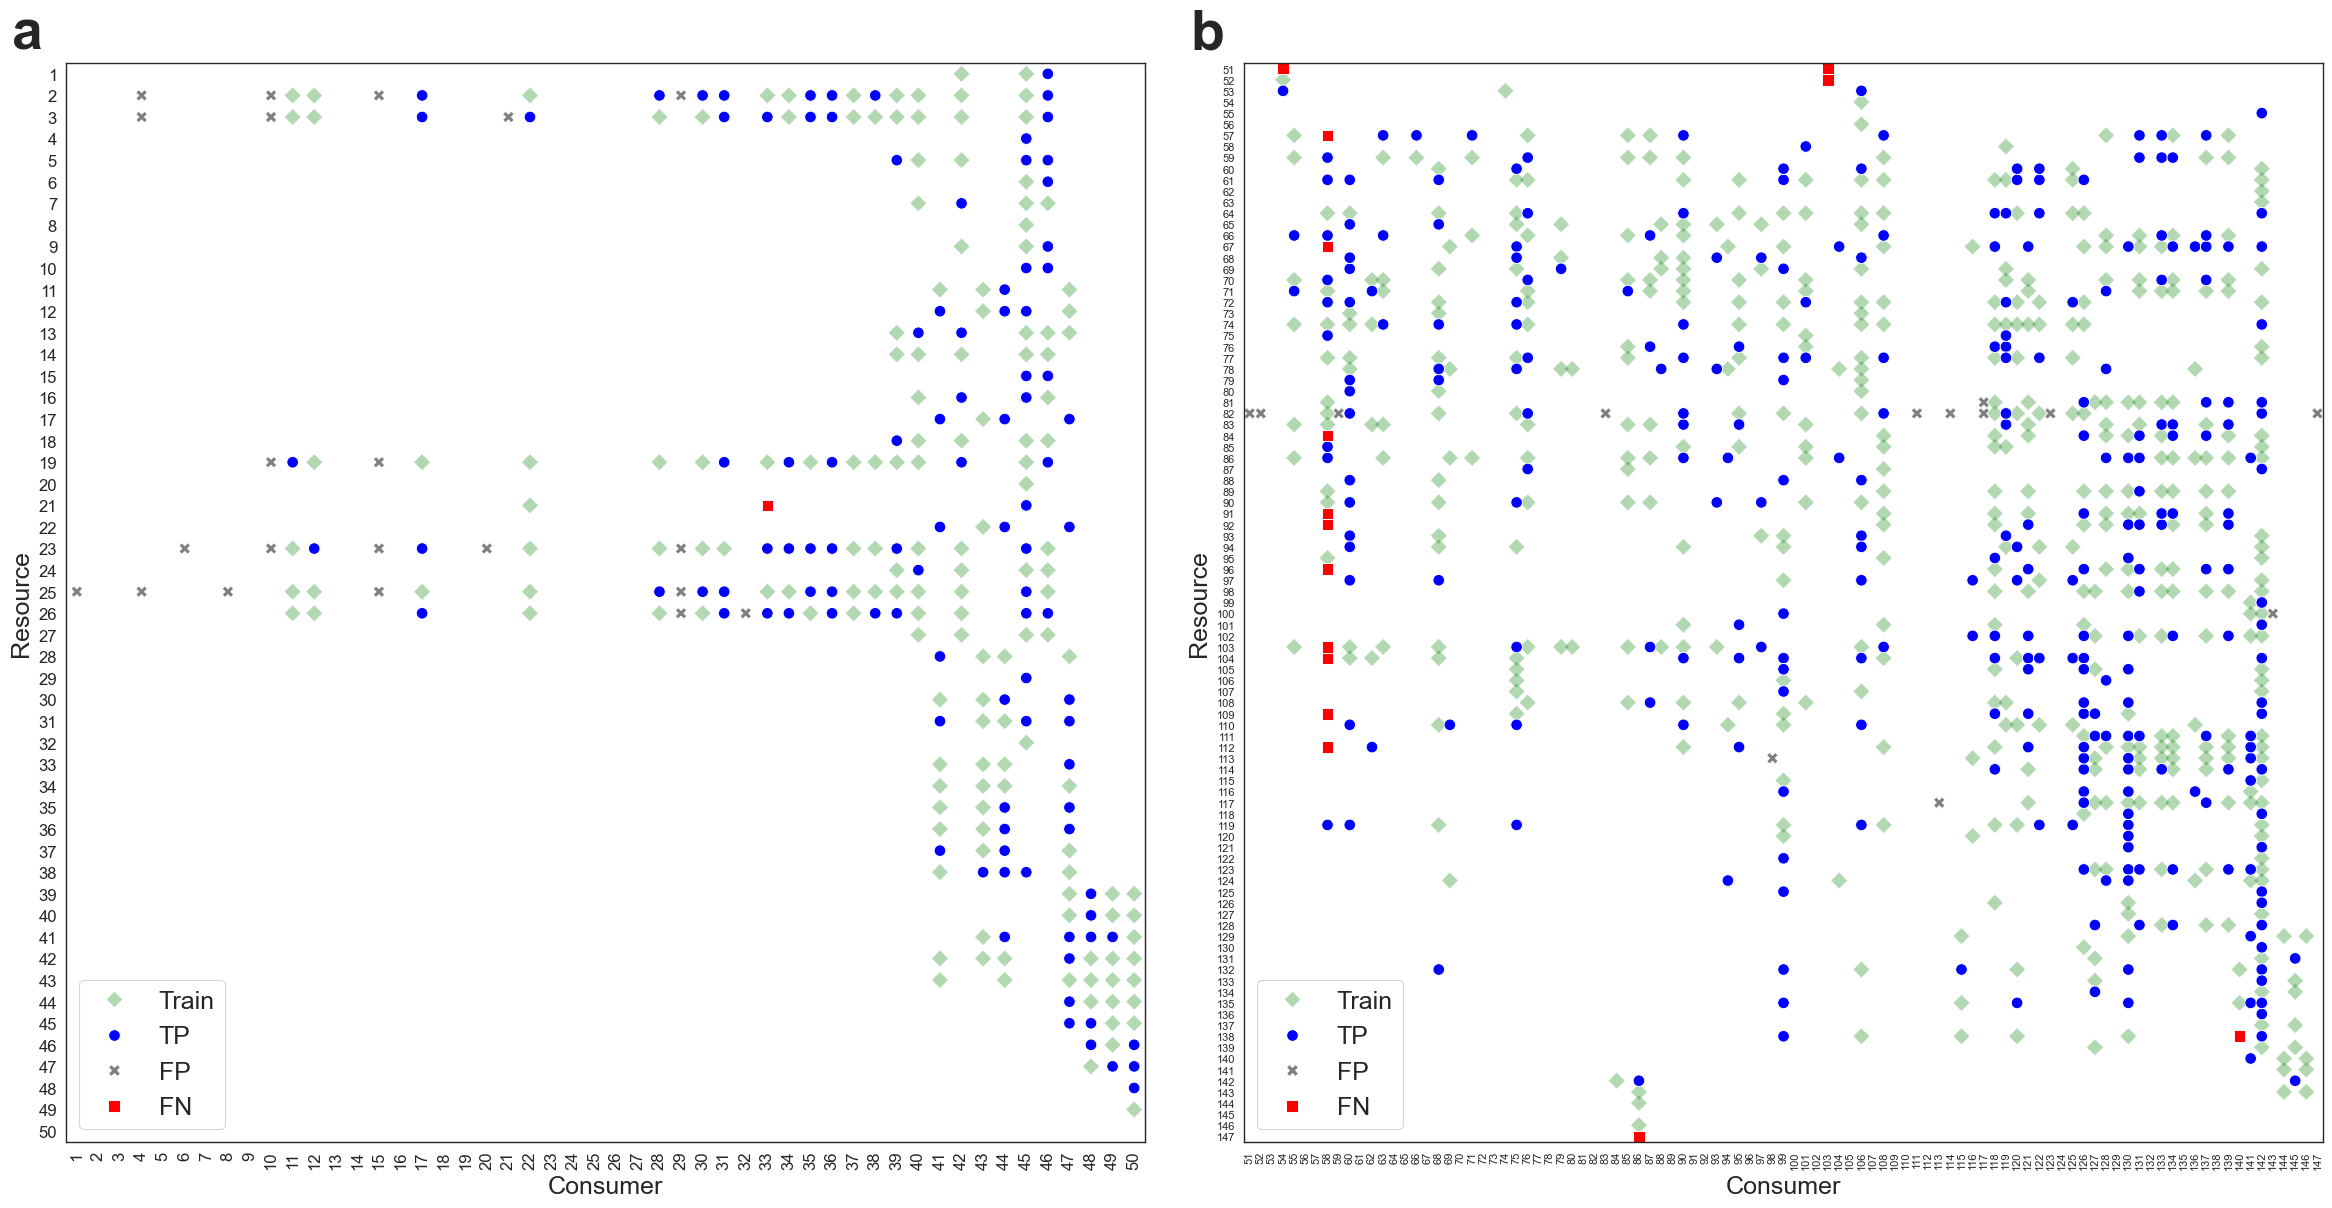

In [1]:
import os
import re
import scipy.io
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix, csr_matrix

# Apply seaborn style
sns.set_theme(context="paper", style="white", font_scale=3)

# =========================
# Figure controls (flags)
# =========================
MIN_NODES = 40

SHOW_TITLES = False
SHOW_TICKS = True

XLAB = "Consumer"
YLAB = "Resource"

PANEL_XTICK_FONTSIZES = [12, 8]   # panel a, panel b
PANEL_YTICK_FONTSIZES = [12, 8]   # panel a, panel b

# =========================
# Numeric axis labels + species key printing
# =========================
USE_NUMERIC_AXIS_LABELS = True
PRINT_SPECIES_KEY = True
EXPORT_SPECIES_KEY_FILE = True
SPECIES_KEY_DIR = "./species_keys"
SPECIES_KEY_FORMAT = "csv"

# =========================
# Plot two specific foodwebs
# =========================
TARGET_FOODWEB_1 = "Tuesday Lake 1984"
TARGET_FOODWEB_2 = "Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2"
PANEL_LETTERS = ["a", "b"]

# === Load foodweb names list ===
foodwebs_list_df = pd.read_csv("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

# === Filter to foodwebs with nodes >= MIN_NODES ===
def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

node_candidates = {
    "n_nodes", "num_nodes", "nodes", "nodecount", "n", "s",
    "species", "numspecies", "numberofspecies", "speciescount"
}

norm_map = {normalize_colname(c): c for c in foodwebs_list_df.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in foodweb_metrics_ecosystem.csv. "
        "Please add one such as 'Nodes' or 'S'."
    )

before_n = len(foodwebs_list_df)
foodwebs_list_df = foodwebs_list_df[foodwebs_list_df[node_col] >= MIN_NODES].copy()
after_n = len(foodwebs_list_df)

print(f"Filtered foodweb list by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Base paths ===
base_csv_path = "../../../src/matlab/data/result_trainRatio_60_backboneRatio_50/confusion_matrix_csv"
base_mat_path = "../../../src/matlab/data/foodwebs_mat"

# =========================
# Choose which foodwebs to iterate
# =========================
all_foodwebs = foodwebs_list_df["Foodweb"].astype(str).tolist()

def resolve_foodweb(target_name, all_names):
    exact = [fw for fw in all_names if fw == target_name]
    if exact:
        return exact[0]

    prefix_matches = [fw for fw in all_names if fw.split("_")[0] == target_name]
    if prefix_matches:
        return prefix_matches[0]

    raise ValueError(
        f"TARGET_FOODWEB='{target_name}' not found in filtered foodweb list. "
        f"Example valid values: {all_names[:5]}"
    )

foodweb_iter = [
    resolve_foodweb(TARGET_FOODWEB_1, all_foodwebs),
    resolve_foodweb(TARGET_FOODWEB_2, all_foodwebs),
]

# =========================
# Build one 1x2 figure
# =========================
fig, axs = plt.subplots(1, 2, figsize=(24, 12))

if len(foodweb_iter) == 1:
    axs = [axs]

global_species_offset = 0

# === Iterate over the selected foodwebs ===
for panel_idx, foodweb in enumerate(foodweb_iter):
    ax = axs[panel_idx]

    print(f"\nProcessing: {foodweb.split('_')[0]}")

    try:
        # === Load CSV prediction results ===
        tp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_TP_links.csv")
        fp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_FP_links.csv")
        fn_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_FN_links.csv")
        train_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_train_links.csv")
        mat_file = os.path.join(base_mat_path, f"{foodweb}.mat")

        tp = pd.read_csv(tp_file).dropna(subset=["Prey", "Predator"])
        fp = pd.read_csv(fp_file).dropna(subset=["Prey", "Predator"])
        fn = pd.read_csv(fn_file).dropna(subset=["Prey", "Predator"])

        # === Load .mat adjacency and metadata ===
        mat_data = scipy.io.loadmat(mat_file)
        net = mat_data["net"]
        taxonomy = [
            str(t[0]) if isinstance(t, (list, np.ndarray)) else str(t)
            for t in mat_data["taxonomy"].flatten()
        ]
        mass = mat_data["mass"].flatten().astype(float)
        mass = np.round(mass * 1000.0, 4)

        # === Sort species by mass ===
        taxonomy_df = pd.DataFrame({"Species": taxonomy, "Mass": mass})
        taxonomy_df = taxonomy_df.dropna().sort_values(by="Mass").reset_index(drop=True)
        sorted_species = taxonomy_df["Species"].tolist()
        species_index = {name: i for i, name in enumerate(sorted_species)}
        N = len(sorted_species)
        sorted_species_reversed = sorted_species[::-1]

        # Number each species globally (continued across panels)
        start_num = global_species_offset + 1
        species_to_num = {sp: start_num + i for i, sp in enumerate(sorted_species)}
        num_to_species = {start_num + i: sp for i, sp in enumerate(sorted_species)}

        if PRINT_SPECIES_KEY:
            key_df = taxonomy_df.copy()
            key_df["Number"] = np.arange(start_num, start_num + len(key_df))
            key_df = key_df[["Number", "Species", "Mass"]].rename(columns={"Mass": "Mass_mg"})
            key_df["Mass_mg"] = key_df["Mass_mg"].map(lambda x: f"{x:.4f}")

            print(f"\nSpecies key for {foodweb} (pretty):")
            print(key_df.to_string(index=False))

            if EXPORT_SPECIES_KEY_FILE:
                out_dir = Path(SPECIES_KEY_DIR)
                out_dir.mkdir(parents=True, exist_ok=True)

                safe_fw = re.sub(r"[^A-Za-z0-9._-]+", "_", str(foodweb)).strip("_")
                ext = "tsv" if SPECIES_KEY_FORMAT.lower() == "tsv" else "csv"
                out_path = out_dir / f"{safe_fw}_species_key.{ext}"

                sep = "\t" if ext == "tsv" else ","
                key_df.to_csv(out_path, sep=sep, index=False, encoding="utf-8")

                print(f"\nSaved species key file to: {out_path.resolve()}")

        # Keep matrix conversion logic intact in case net format varies
        if isinstance(net, coo_matrix):
            net = net.tocsr()
        elif isinstance(net, (np.ndarray, list)):
            net = csr_matrix(net)

        idx_sorted = [taxonomy.index(sp) for sp in sorted_species]
        adj_sorted = net[np.ix_(idx_sorted, idx_sorted)].toarray().astype(float)

        # === Filter predictions to valid species ===
        tp = tp[tp["Prey"].isin(species_index) & tp["Predator"].isin(species_index)]
        fp = fp[fp["Prey"].isin(species_index) & fp["Predator"].isin(species_index)]
        fn = fn[fn["Prey"].isin(species_index) & fn["Predator"].isin(species_index)]

        # === Build DataFrame for Predation Matrix
        def make_df(df, label):
            return pd.DataFrame({
                "PreyIdx": df["Prey"].map(species_index),
                "PredIdx": df["Predator"].map(species_index),
                "Label": label
            })

        df_pm = pd.concat([
            make_df(tp, "TP"),
            make_df(fp, "FP"),
            make_df(fn, "FN")
        ]).dropna().astype({"PreyIdx": int, "PredIdx": int})
        df_pm["PreyIdx"] = N - 1 - df_pm["PreyIdx"]

        # === Load Training Links (if available)
        df_train = None
        if os.path.isfile(train_file):
            train = pd.read_csv(train_file).dropna(subset=["Prey", "Predator"])
            train = train[train["Prey"].isin(species_index) & train["Predator"].isin(species_index)]
            df_train = pd.DataFrame({
                "PreyIdx": train["Prey"].map(species_index),
                "PredIdx": train["Predator"].map(species_index),
                "Label": "Train"
            })
            df_train["PreyIdx"] = N - 1 - df_train["PreyIdx"]

        # === Panel label
        ax.text(
            -0.05, 1.05, PANEL_LETTERS[panel_idx],
            transform=ax.transAxes,
            fontsize=40,
            fontweight="bold",
            va="top",
            ha="left",
            clip_on=False
        )

        # === Plot training links first (background)
        if df_train is not None:
            sns.scatterplot(
                data=df_train,
                x="PredIdx",
                y="PreyIdx",
                hue="Label",
                style="Label",
                markers={"Train": "D"},
                palette={"Train": "green"},
                alpha=0.3,
                s=70,
                legend="brief",
                ax=ax
            )

        # === Plot TP, FP, FN
        sns.scatterplot(
            data=df_pm,
            x="PredIdx",
            y="PreyIdx",
            hue="Label",
            style="Label",
            markers={"TP": "o", "FP": "X", "FN": "s", "Train": "D"},
            palette={"TP": "blue", "FP": "gray", "FN": "red", "Train": "green"},
            s=70,
            ax=ax
        )

        # =========================
        # Professional axis styling
        # =========================
        ax.invert_yaxis()
        ax.set_xlim(-0.5, N - 0.5)
        ax.set_ylim(-0.5, N - 0.5)
        ax.set_aspect("equal", adjustable="box")

        ax.set_xlabel(XLAB, fontsize=18)
        ax.set_ylabel(YLAB, fontsize=18)

        if SHOW_TICKS:
            ax.set_xticks(range(N))
            ax.set_yticks(range(N))

            x_tick_fs = PANEL_XTICK_FONTSIZES[panel_idx]
            y_tick_fs = PANEL_YTICK_FONTSIZES[panel_idx]

            if USE_NUMERIC_AXIS_LABELS:
                x_labels = [str(species_to_num[sp]) for sp in sorted_species]
                y_labels = [str(species_to_num[sp]) for sp in sorted_species_reversed]

                ax.set_xticklabels(x_labels, rotation=90, fontsize=x_tick_fs)
                ax.set_yticklabels(y_labels, fontsize=y_tick_fs)
            else:
                ax.set_xticklabels(sorted_species, rotation=90, fontsize=x_tick_fs)
                ax.set_yticklabels(sorted_species_reversed, fontsize=y_tick_fs)

            ax.tick_params(axis="both", which="both", length=3)
        else:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.tick_params(axis="both", which="both", length=0)

        if SHOW_TITLES:
            ax.set_title(foodweb, fontsize=12)

        ax.legend(loc="lower left", prop={"size": 18}, title="")

        # Update numbering offset so the next panel continues
        global_species_offset += N

    except Exception as e:
        print(f"Skipping {foodweb} due to error: {e}")
        ax.set_axis_off()

plt.tight_layout()
plt.show()

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_63094/1542609290.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_63094/1542609290.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_63094/1542609290.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_63094/1542609290.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

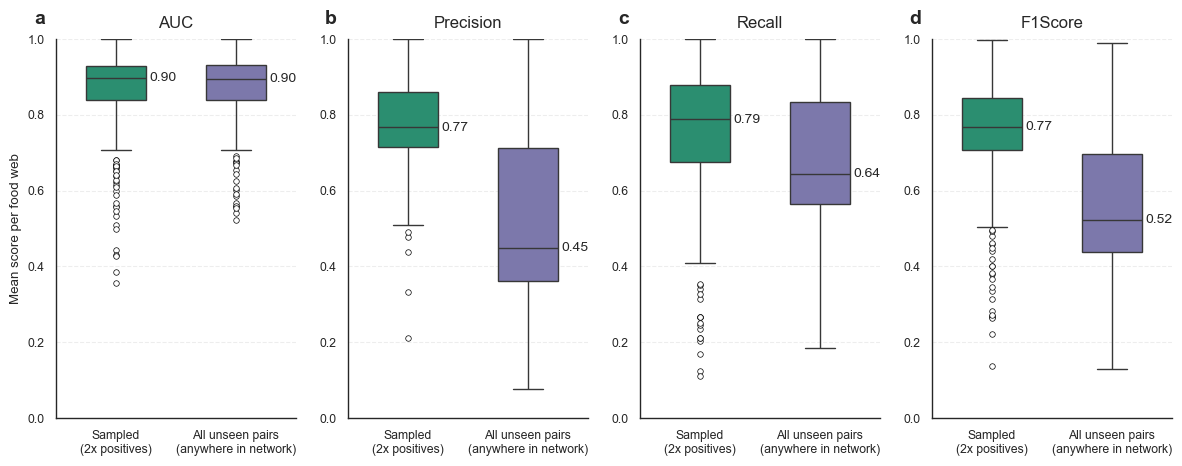

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# =========================
# Style (match old snippet)
# =========================
sns.set_theme(context="paper", style="white", font_scale=1.0)


# =========================
# Config
# =========================
RESULTS_DIR_SAMPLED = Path("../../../src/matlab/data/result_evaluate_on_all_unseen-false/prediction_scores_logs")
RESULTS_DIR_ALL_UNSEEN = Path("../../../src/matlab/data/result_evaluate_on_all_unseen-true/prediction_scores_logs")

METRICS = ["AUC", "Precision", "Recall", "F1Score"]

K_TARGET = None
K_COL = "K"

GLOB_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"


# =========================
# Helpers
# =========================
def parse_regime_from_name(fname: str) -> str:
    m = re.search(r"evaluate_on_all_unseen-(true|false)", fname.lower())
    if not m:
        return "unknown"
    return "all_unseen" if m.group(1) == "true" else "sampled"


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, regime_hint=None):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, present_metrics + [K_COL])

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    regime = parse_regime_from_name(csv_path.name)
    if regime == "unknown" and regime_hint in {"sampled", "all_unseen"}:
        regime = regime_hint

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Regime": regime,
        "n_rows": int(len(df)),
        "file": csv_path.name,
        "folder": str(csv_path.parent),
    }

    for m in METRICS:
        if m in df.columns:
            vals = df[m].dropna().values
            out[f"{m}_mean"] = float(np.mean(vals)) if vals.size else np.nan
        else:
            out[f"{m}_mean"] = np.nan

    if np.isnan(out["AUC_mean"]):
        return None

    return out


def load_folder(folder: Path, regime_hint: str):
    csv_files = sorted(folder.glob(GLOB_PATTERN))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {GLOB_PATTERN}"
        )

    rows = []
    for p in csv_files:
        rec = load_one_csv(p, regime_hint=regime_hint)
        if rec is not None and rec["Regime"] in {"sampled", "all_unseen"}:
            rows.append(rec)
    return rows


# =========================
# Load all CSVs (two folders)
# =========================
rows = []
rows += load_folder(RESULTS_DIR_SAMPLED, regime_hint="sampled")
rows += load_folder(RESULTS_DIR_ALL_UNSEEN, regime_hint="all_unseen")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading both folders. Check patterns or CSV columns.")


# =========================
# Optional: enforce one row per (Foodweb, Regime)
# =========================
mean_cols = [f"{m}_mean" for m in METRICS]
df_all = (
    df_all
    .groupby(["Foodweb", "Regime"], as_index=False)[mean_cols]
    .mean()
)

# =========================
# Plot: 1x4 boxplots + points (style intact)
# =========================
order = ["sampled", "all_unseen"]

label_map_short = {
    "sampled": "Sampled\n(2x positives)",
    "all_unseen": "All unseen pairs\n(anywhere in network)",
}

palette = {
    "sampled": "#1b9e77",
    "all_unseen": "#7570b3",
}

fig, axes = plt.subplots(1, 4, figsize=(12, 5))
letters = ["a", "b", "c", "d"]

for idx, (ax, metric_name) in enumerate(zip(axes, METRICS)):
    ycol = f"{metric_name}_mean"

    sns.boxplot(
        data=df_all,
        x="Regime",
        y=ycol,
        order=order,
        palette=[palette[o] for o in order],
        width=0.5,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    # Annotate one summary value per box (median across food webs)
    for j, regime_name in enumerate(order):
        vals = df_all.loc[df_all["Regime"] == regime_name, ycol].dropna()
        if vals.empty:
            continue

        stat = vals.median()

        ax.text(
            j + 0.28,
            stat,
            f"{stat:.2f}",
            ha="left",
            va="center",
            fontsize=10,
        )

    # Optional points overlay
    # sns.stripplot(
    #     data=df_all,
    #     x="Regime",
    #     y=ycol,
    #     order=order,
    #     palette=[palette[o] for o in order],
    #     dodge=False,
    #     jitter=0.20,
    #     size=2.0,
    #     alpha=0.75,
    #     edgecolor="black",
    #     linewidth=0.2,
    #     ax=ax,
    # )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([label_map_short[o] for o in order], rotation=0)

    if metric_name == "AUC":
        ax.set_ylabel("Mean score per food web")
    else:
        ax.set_ylabel("")

    ax.set_title(metric_name, fontsize=12, pad=8)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    ax.annotate(
        letters[idx],
        xy=(0, 1), xycoords="axes fraction",
        xytext=(-8, 8), textcoords="offset points",
        ha="right", va="bottom",
        fontsize=14, fontweight="bold",
        annotation_clip=False,
    )

# fig.supxlabel("Test negatives", y=0.03, fontsize=11)

# fig.suptitle(
#     "Sampled negatives vs possible links anywhere in the network (mean per food web)",
#     y=1.02,
#     fontsize=12,
# )

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()